In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"

columns = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
]

df = pd.read_csv(url, names=columns)

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [5]:
df.shape

(1728, 7)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [7]:
df["class"].value_counts()

,count
class,
unacc,1210
acc,384
good,69
vgood,65


In [8]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

encoder = LabelEncoder()

for column in df_encoded.columns:
    df_encoded[column] = encoder.fit_transform(df_encoded[column])

df_encoded.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [9]:
X = df_encoded.drop("class", axis=1)
y = df_encoded["class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1728, 6)
y shape: (1728,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1382, 6)
Testing data: (346, 6)


In [11]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [12]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 2 2 2 0 2 2 0 2 2]


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9855491329479769
Accuracy Percentage: 98.55491329479769 %


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        77
           1       0.93      1.00      0.97        14
           2       1.00      0.99      1.00       242
           3       1.00      0.85      0.92        13

    accuracy                           0.99       346
   macro avg       0.97      0.96      0.96       346
weighted avg       0.99      0.99      0.99       346



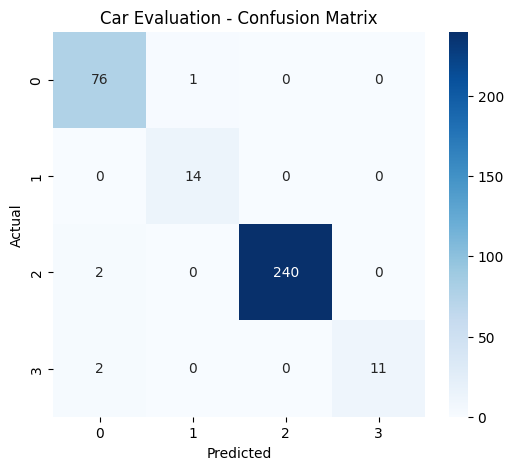

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Car Evaluation - Confusion Matrix")
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for column in df.columns:
    encoders[column] = LabelEncoder()
    encoders[column].fit(df[column])

In [18]:
new_car_df = pd.DataFrame([new_car])

new_car_encoded = pd.DataFrame()

for column in X.columns:
    new_car_encoded[column] = encoders[column].transform(
        new_car_df[column]
    )

prediction = model.predict(new_car_encoded)[0]

predicted_class = encoders["class"].inverse_transform([prediction])[0]

print("Predicted Car Evaluation:", predicted_class)

Predicted Car Evaluation: vgood


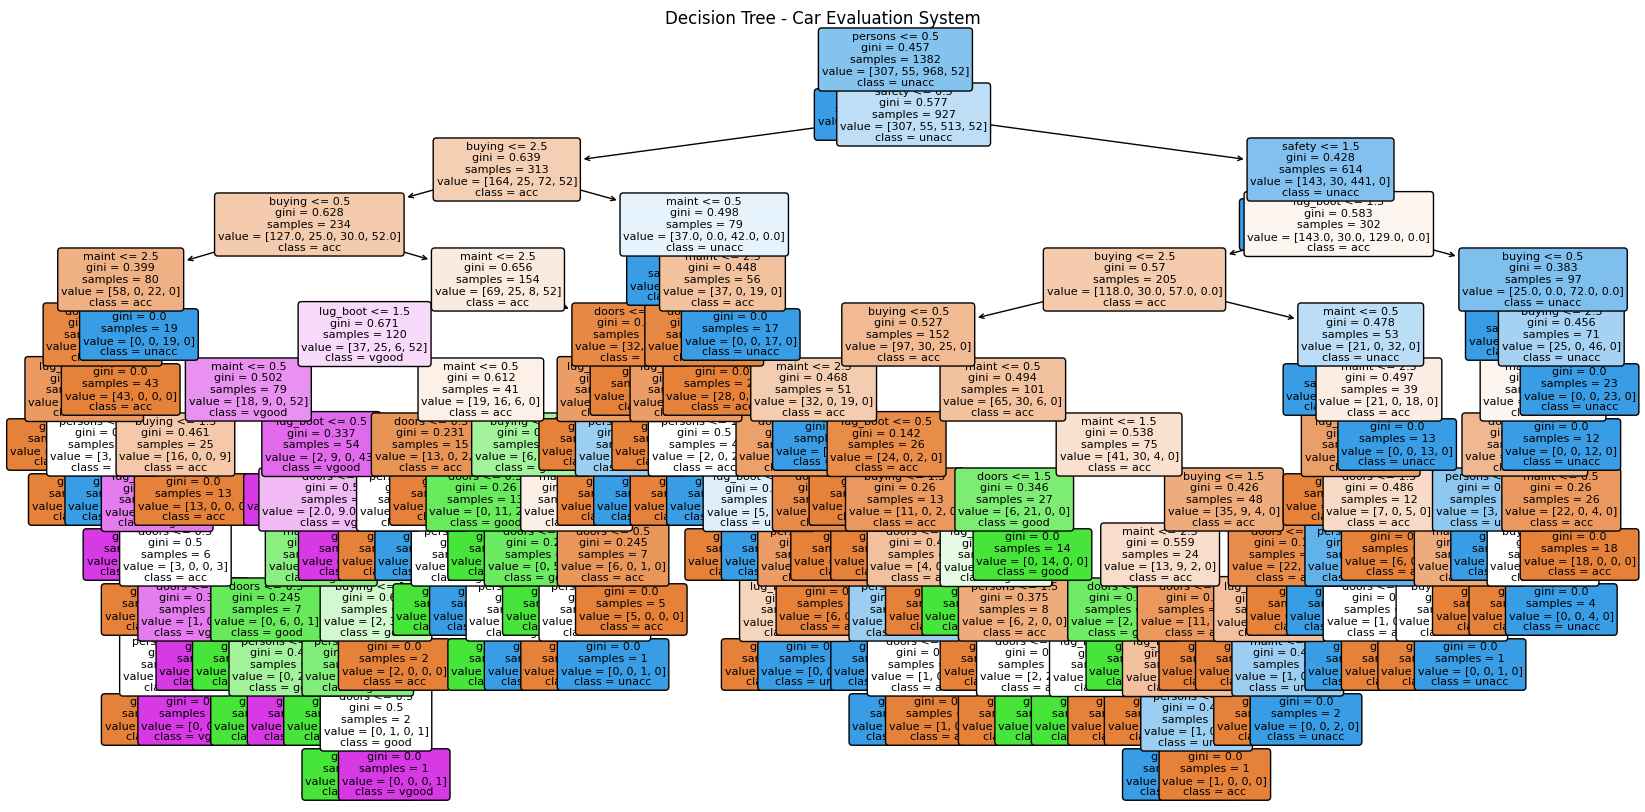

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=encoders["class"].classes_,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree - Car Evaluation System")
plt.show()

In [20]:
import joblib

joblib.dump(model, "car_evaluation_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [21]:
import os

print(os.path.exists("car_evaluation_model.pkl"))

True


In [22]:
import joblib

# Load the saved model
loaded_model = joblib.load("car_evaluation_model.pkl")

# Test the loaded model
test_prediction = loaded_model.predict(new_car_encoded)[0]

test_result = encoders["class"].inverse_transform([test_prediction])[0]

print("Loaded Model Prediction:", test_result)

Loaded Model Prediction: vgood
